In [1]:
# Cell 1 — Setup
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DB_PATH = "../data/commodity_credit.db"
conn = sqlite3.connect(DB_PATH)

def query(sql):
    return pd.read_sql(sql, conn)

print("Connected to SQLite!")

Connected to SQLite!


In [2]:
# Cell 2 — Load data from SQLite
df = query("""
    SELECT
        o.produto,
        o.sigla_uf,
        o.id_referencia_bacen,
        o.numero_ordem,
        o.valor_parcela_credito,
        o.taxa_juro,
        o.valor_receita_bruta_esperada,
        o.valor_produtividade_obtida,
        o.valor_previsao_producao,
        CAST(
            JULIANDAY(o.data_vencimento) - JULIANDAY(o.data_emissao)
            AS INTEGER
        ) AS prazo_dias,
        MAX(CASE
            WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
            THEN 1 ELSE 0
        END) AS inadimplente
    FROM operacoes o
    LEFT JOIN saldo s
        ON o.id_referencia_bacen = s.id_referencia_bacen
        AND o.numero_ordem = s.numero_ordem
    WHERE o.valor_parcela_credito > 0
      AND o.taxa_juro > 0
    GROUP BY
        o.produto, o.sigla_uf, o.id_referencia_bacen, o.numero_ordem,
        o.valor_parcela_credito, o.taxa_juro, o.valor_receita_bruta_esperada,
        o.valor_produtividade_obtida, o.valor_previsao_producao,
        o.data_vencimento, o.data_emissao
""")

print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDefault rate: {df['inadimplente'].mean()*100:.2f}%")

Shape: (499972, 11)

Missing values:
produto                              0
sigla_uf                             0
id_referencia_bacen                  0
numero_ordem                         0
valor_parcela_credito                0
taxa_juro                            0
valor_receita_bruta_esperada    117168
valor_produtividade_obtida      480626
valor_previsao_producao         103779
prazo_dias                           0
inadimplente                         0
dtype: int64

Default rate: 1.46%


In [4]:
# Cell 3 — Feature engineering and Isolation Forest
# Fill missing values with median per produto
features = ["valor_parcela_credito", "taxa_juro", 
            "valor_receita_bruta_esperada", "valor_previsao_producao",
            "prazo_dias"]

df_model = df.copy()
for col in features:
    df_model[col] = df_model.groupby("produto")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing after fill:")
print(df_model[features].isnull().sum())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features])

# Isolation Forest
print("\nRunning Isolation Forest...")
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)
df_model["anomaly_score"] = iso.decision_function(X_scaled)
df_model["is_anomaly"] = iso.predict(X_scaled)

n_anomalies = (df_model["is_anomaly"] == -1).sum()
print(f"Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df_model)*100:.1f}%)")
print(f"\nAnomalies by commodity:")
print(df_model[df_model["is_anomaly"] == -1]["produto"].value_counts())

Missing after fill:
valor_parcela_credito           0
taxa_juro                       0
valor_receita_bruta_esperada    0
valor_previsao_producao         0
prazo_dias                      0
dtype: int64

Running Isolation Forest...
Anomalies detected: 24,997 (5.0%)

Anomalies by commodity:
produto
CANA-DE-AÇUCAR    12832
CAFÉ               8834
LARANJA            3331
Name: count, dtype: int64


Running PCA...
Variance explained: 46.8%


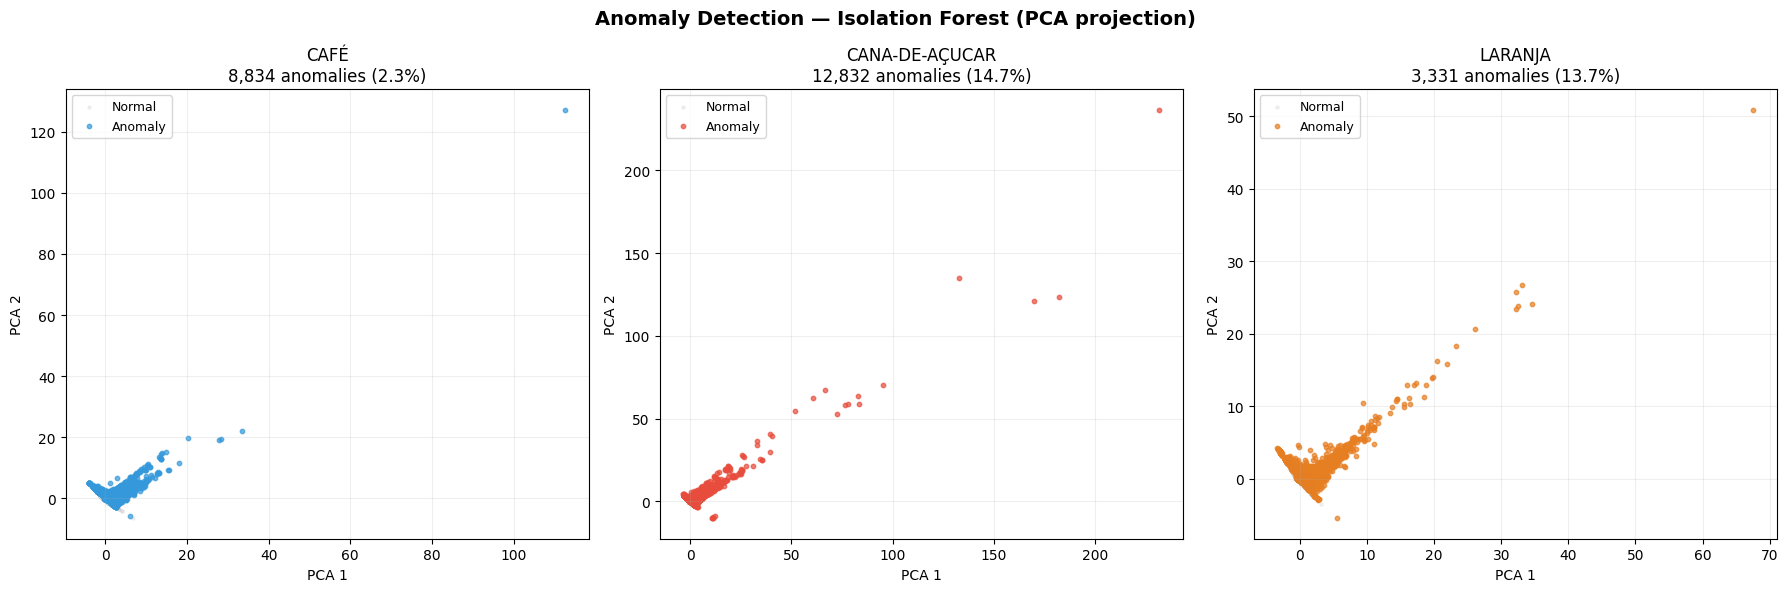

Saved!


In [5]:
# Cell 4 — PCA Visualization
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_model["pca1"] = X_pca[:, 0]
df_model["pca2"] = X_pca[:, 1]

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Anomaly Detection — Isolation Forest (PCA projection)", 
             fontsize=14, fontweight="bold")

commodities = ["CAFÉ", "CANA-DE-AÇUCAR", "LARANJA"]
colors_commodity = ["#3498DB", "#E74C3C", "#E67E22"]

for ax, commodity, color in zip(axes, commodities, colors_commodity):
    df_prod = df_model[df_model["produto"] == commodity]
    
    normal = df_prod[df_prod["is_anomaly"] == 1]
    anomaly = df_prod[df_prod["is_anomaly"] == -1]
    
    ax.scatter(normal["pca1"], normal["pca2"],
               c="lightgray", alpha=0.3, s=5, label="Normal")
    ax.scatter(anomaly["pca1"], anomaly["pca2"],
               c=color, alpha=0.7, s=10, label="Anomaly")
    
    ax.set_title(f"{commodity}\n{len(anomaly):,} anomalies ({len(anomaly)/len(df_prod)*100:.1f}%)")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("../data/bq3_isolation_forest_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [6]:
# Cell 5 — Save anomalies and summary
# Save anomaly results to SQLite
df_anomalies = df_model[df_model["is_anomaly"] == -1].copy()
df_anomalies.to_sql("anomalies", conn, if_exists="replace", index=False)

print("=== ANOMALY SUMMARY ===\n")
print(f"Total anomalies: {len(df_anomalies):,}")
print(f"\nBy commodity:")
print(df_anomalies.groupby("produto").agg(
    total=("is_anomaly", "count"),
    ticket_medio=("valor_parcela_credito", "mean"),
    taxa_juro_media=("taxa_juro", "mean"),
    pct_inadimplente=("inadimplente", "mean")
).round(2).to_string())

print(f"\nTop 10 highest anomaly score (most anomalous):")
print(df_anomalies.nsmallest(10, "anomaly_score")[
    ["produto", "sigla_uf", "valor_parcela_credito", 
     "taxa_juro", "prazo_dias", "inadimplente", "anomaly_score"]
].to_string(index=False))

print("\nSaved to SQLite!")

=== ANOMALY SUMMARY ===

Total anomalies: 24,997

By commodity:
                total  ticket_medio  taxa_juro_media  pct_inadimplente
produto                                                               
CAFÉ             8834    3676131.04            10.70              0.02
CANA-DE-AÇUCAR  12832    2626280.88             8.87              0.03
LARANJA          3331    1348642.41             8.48              0.03

Top 10 highest anomaly score (most anomalous):
       produto sigla_uf  valor_parcela_credito  taxa_juro  prazo_dias  inadimplente  anomaly_score
CANA-DE-AÇUCAR       MS           150000000.00      14.10        1460             0      -0.273051
CANA-DE-AÇUCAR       MS            30000000.00       8.63         820             0      -0.266961
CANA-DE-AÇUCAR       MS           130000000.00       1.80        1368             0      -0.266961
CANA-DE-AÇUCAR       SP            44858265.19       1.75        1794             0      -0.259822
CANA-DE-AÇUCAR       SP            250